In [1]:
import numpy as np
from PIL import Image
from IPython.display import display

In [2]:
from __future__ import annotations

NUM_ROWS = 28
NUM_COLS = 28
NUM_LABELS = 10

class Data:
  def __init__(self, pixels: list[list[int]], label: int):
    self.pixels = pixels
    self.flattened_pixels: list[int] = []
    for row in self.pixels:
      assert len(row) == NUM_ROWS
      self.flattened_pixels.extend(row)
    self.flattened_pixels = [pixel / 255.0 for pixel in self.flattened_pixels]
    
    self.label = label
  
  @classmethod
  def from_csv_row(cls, csv: list[int]) -> Data:
    label = csv[0]
    pixels: list[list[int]] = []
    for row in range(NUM_ROWS):
      start_index = 1 + row * NUM_ROWS
      pixels.append(csv[start_index : start_index + NUM_COLS])

    return cls(pixels, label)
  
  def to_image(self) -> Image:
    pixel_array = np.array(self.pixels, dtype=np.uint8)
    return Image.fromarray(pixel_array, mode='L')
  
  def label_to_one_hot(self) -> list[int]:
    result = [0] * NUM_LABELS
    result[self.label] = 1
    return result

In [3]:
lines: list[str] = []
datas: list[Data] = []

with open('data/MNIST_CSV/mnist_train.csv') as f:
  lines = f.readlines()

for line in lines:
  datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [4]:
print(datas[0].label)
print(datas[0].label_to_one_hot())
display(datas[0].to_image())

5
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [5]:
distinct_labels = set()
for data in datas:
  distinct_labels.add(data.label)

In [6]:
distinct_labels

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [23]:
from src.deep_learning.layer import get_random_layer
from src.deep_learning.multi_layer_perceptron import MultiLayerPerceptron
from src.deep_learning.op import TANH
from src.deep_learning.value import Value

from src.deep_learning.util import zero_all_gradients
from src.deep_learning.util import softmax
from src.deep_learning.util import cross_entropy
from datetime import datetime

In [24]:
# build graph

input_values = [Value(0.0, label=f'pixel_{i}') for i in range(NUM_ROWS*NUM_COLS)]
output_values = [Value(0.0, label=f'label_{i}') for i in range(len(distinct_labels))]

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_random_layer(128, NUM_ROWS*NUM_COLS, TANH),
        get_random_layer(NUM_LABELS, 128, TANH),
    ],
)
predicted_output = multi_layer_perceptron.build_graph(input_values)
softmax_output = softmax(predicted_output)
loss = cross_entropy(
    distribution=output_values,
    predicted_distribution=softmax_output,
)

## debugging

In [19]:
loss.gradient

1.0

In [20]:
for value in softmax_output:
  print(value.gradient)

-1.6387221503171325e-15
-2.553354503136456e-15
-2.078150277585007e-15
-1.6838966086483253e-15
-2.5535177030407734e-15
-24.948654712543433
-3.49744329807349e-16
-2.48358984769353e-15
-2.5260881516425977e-15
-2.4730596288605524e-15


In [21]:
import matplotlib.pyplot as plt

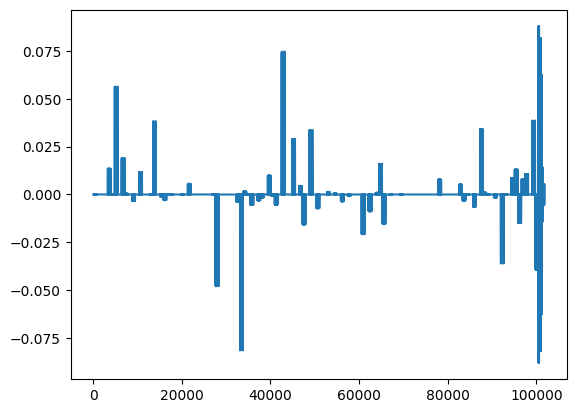

In [22]:
i = 0
gradients: list[float] = []
for layer in multi_layer_perceptron.layers:
  for neuron in layer.neurons:
    for weight in neuron.weight_values:
      gradients.append(weight.gradient)
    gradients.append(neuron.bias_value.gradient)
plt.plot(gradients)

## end debugging

In [25]:
data_index = 0

In [26]:
losses: list[float] = []

In [ ]:
for i in range(len(datas) * 2):
  # compute loss
  data = datas[data_index]
  for input_value, pixel in zip(input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  loss.forward()
  losses.append(loss.data)

  if i % 100 == 0 and i > 0:
    window = losses[-100:]
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} mean_t100_loss={sum(window)/len(window):.4f}')

  # backwards
  zero_all_gradients(loss)
  loss.gradient = 1.0
  loss.backward()

  # adjust parameters
  alpha = 0.01
  for layer in multi_layer_perceptron.layers:
    for neuron in layer.neurons:
      for weight_value in neuron.weight_values:
        weight_value.data = weight_value.data + (weight_value.gradient * -alpha)
      neuron.bias_value.data = neuron.bias_value.data + (neuron.bias_value.gradient * -alpha)

  # update state
  data_index = (data_index + 1) % len(datas)

19:51:29 i=100 mean_t100_loss=3.8071
19:52:09 i=200 mean_t100_loss=3.7105
19:52:48 i=300 mean_t100_loss=3.4008
19:53:27 i=400 mean_t100_loss=3.5131
19:54:07 i=500 mean_t100_loss=3.0827
19:54:46 i=600 mean_t100_loss=3.3550
19:55:26 i=700 mean_t100_loss=3.1511
19:56:06 i=800 mean_t100_loss=3.0852
19:56:48 i=900 mean_t100_loss=3.0093
19:57:39 i=1000 mean_t100_loss=3.0527
19:58:36 i=1100 mean_t100_loss=2.9108
19:59:20 i=1200 mean_t100_loss=3.1617
20:00:12 i=1300 mean_t100_loss=3.1661
20:01:06 i=1400 mean_t100_loss=3.0172


In [16]:
import matplotlib.pyplot as plt

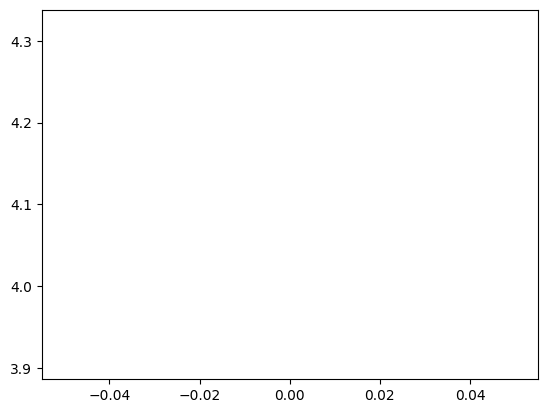

In [17]:
# noisy
plt.plot(losses)

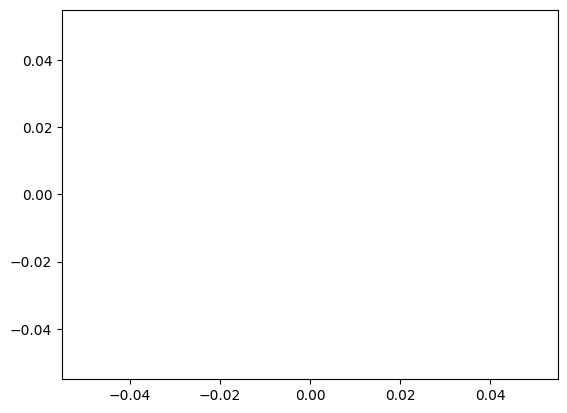

In [18]:
# smooth
mean_t100_losses: list[float] = []
for i in range(100, len(losses)):
  mean_t100_losses.append(sum(losses[i-100:i]) / 100)

plt.plot(mean_t100_losses)